# Task 4: Performance Evaluation and Model Comparison

Use ModelEvaluationUseCase and load 5 trained models. Use evaluation metric (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC), plot curves and show error profiling summaries.


In [5]:
import os
import sys
# Add src to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), 'src')))

from di.container import AppContainer
from IPython.display import Image, display

# Setup Dependency Injection Container
container = AppContainer()
container.config.from_dict({
    "data": {
        "data_dir": os.path.join(os.getcwd(), "data")
    }
})
container.logger().info("Container initialized inside Task 4 notebook.")


2026-07-17 19:26:05,714 | INFO     | [ML_CW] Container initialized inside Task 4 notebook.


In [6]:
# Run performance evaluation use case
eval_usecase = container.model_evaluation_usecase()
model_dir = os.path.join(os.getcwd(), "outputs/models")
output_dir = os.path.join(os.getcwd(), "outputs/task4")

metrics_df = eval_usecase.execute(model_dir, output_dir)
metrics_df


2026-07-17 19:26:05,725 | INFO     | [ML_CW] Executing ModelEvaluationUseCase...
2026-07-17 19:26:05,827 | INFO     | [ML_CW] Loaded processed data: 45175 rows
2026-07-17 19:26:05,843 | INFO     | [ML_CW] Test set: 9035 rows x 18 features.
2026-07-17 19:26:05,846 | INFO     | [ML_CW] Loaded model: Logistic Regression
2026-07-17 19:26:05,853 | INFO     | [ML_CW] Loaded model: KNN
2026-07-17 19:26:05,915 | INFO     | [ML_CW] Loaded model: Random Forest
2026-07-17 19:26:05,919 | INFO     | [ML_CW] Loaded model: XGBoost
2026-07-17 19:26:05,923 | INFO     | [ML_CW] Loaded model: ANN
2026-07-17 19:26:05,924 | INFO     | [ML_CW] Evaluating Logistic Regression...
2026-07-17 19:26:05,961 | INFO     | [ML_CW] Evaluating KNN...
2026-07-17 19:26:06,918 | INFO     | [ML_CW] Evaluating Random Forest...
2026-07-17 19:26:07,273 | INFO     | [ML_CW] Evaluating XGBoost...
2026-07-17 19:26:07,316 | INFO     | [ML_CW] Evaluating ANN...
2026-07-17 19:26:07,357 | INFO     | [ML_CW] Validation Metrics Table:

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.814278,0.587539,0.841964,0.692110,0.908562,0.781057
KNN,0.837521,0.695147,0.613839,0.651968,0.889397,0.747813
Random Forest,0.832097,0.623253,0.816071,0.706747,0.913645,0.795565
XGBoost,0.835639,0.623004,0.853571,0.720286,0.926542,0.827052
ANN,0.820144,0.601452,0.813839,0.691709,0.908298,0.778861


--- ROC Curves ---


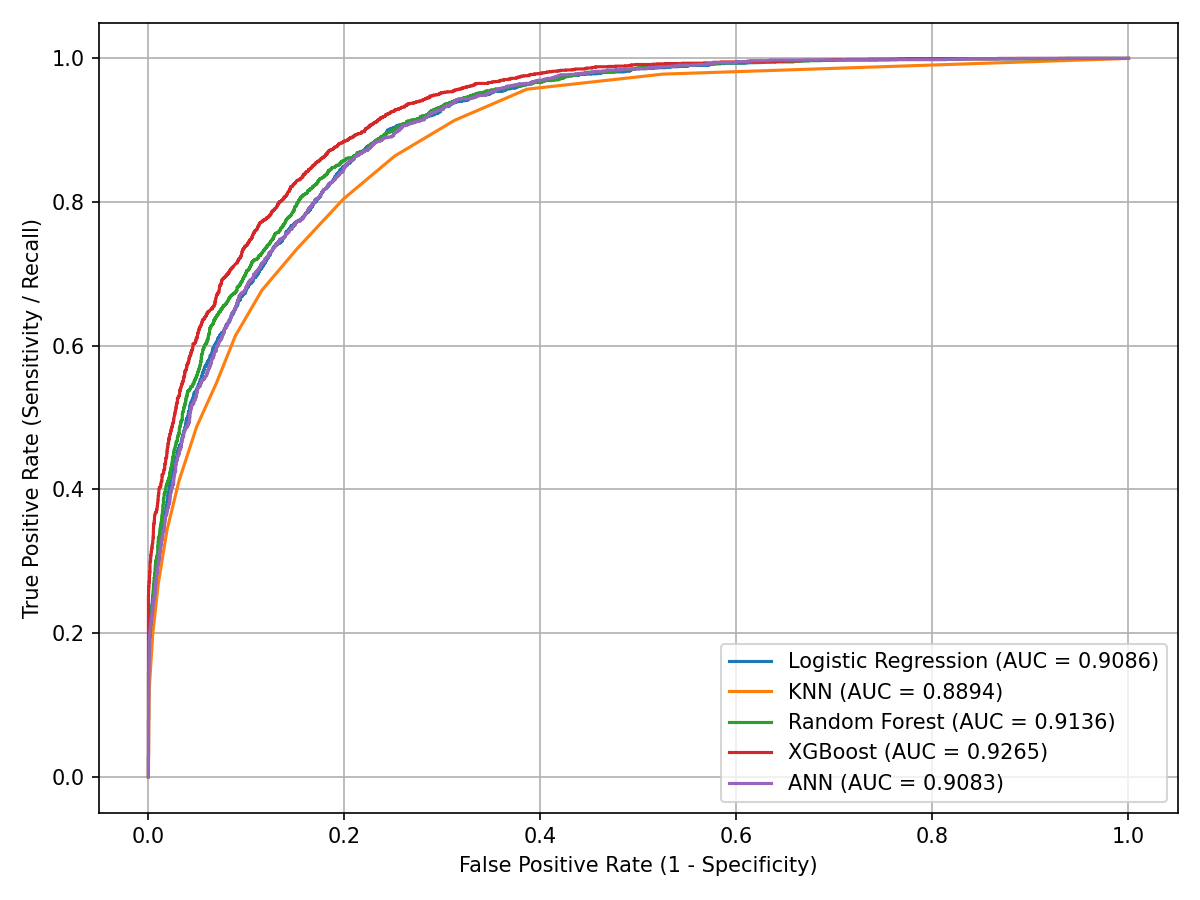


--- Precision-Recall Curves ---


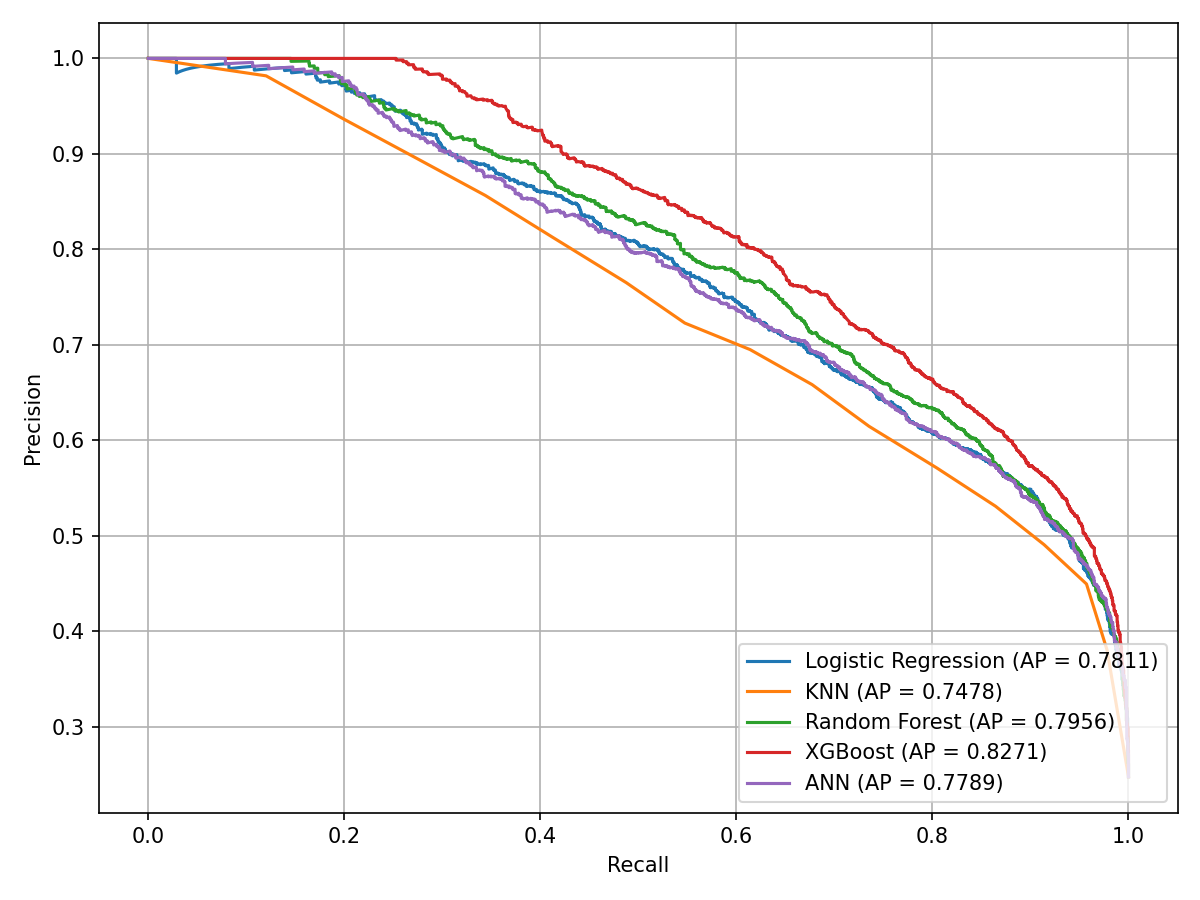

In [7]:
# ROC Curves and Precision-Recall Curves
print("--- ROC Curves ---")
display(Image(os.path.join(output_dir, "roc_curves.png")))

print("\n--- Precision-Recall Curves ---")
display(Image(os.path.join(output_dir, "pr_curves.png")))


In [8]:
# Display Demographic Error Profiling Summary
with open(os.path.join(output_dir, "error_summary.txt"), "r") as f:
    summary = f.read()
print(summary)



--- Error Profile by 'sex' ---
        Total Instances  Errors Count  Error Rate (%)  False Positives  False Negatives
sex                                                                                    
Male               6093          1249           20.50             1006              243
Female             2942           236            8.02              151               85

--- Error Profile by 'edu_group' ---
              Total Instances  Errors Count  Error Rate (%)  False Positives  False Negatives
edu_group                                                                                    
Advanced                  768           155           20.18              135               20
Bachelors                1512           302           19.97              238               64
Some-College             2711           484           17.85              400               84
High-School              2915           474           16.26              364              110
Low           